In [5]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [9]:
# Import data
X = pd.read_csv("./data/mic_reduced.csv")
X = X.set_index('Genome ID')

In [10]:
# Plot BIC function
def plot_BIC(bic, max_k):
    
    #Find best k
    best_k = np.argmin(bic) + 1

    plt.figure(figsize=(10,5))
    plt.plot(range(1, max_k), bic, marker="o")

    plt.axvline(
        x=best_k,
        color="red",
        linestyle="--",
        label=f"Best K: {best_k}"
    )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("BIC Score")
    plt.title("BIC vs. Number of Clusters")

    plt.grid()
    plt.show()

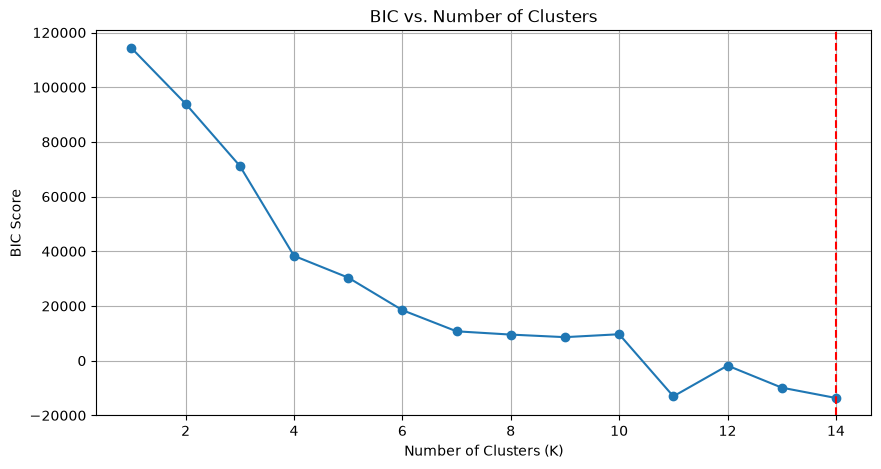

In [11]:
# Find the best K using BIC
bic = []
max_k = 15

for k in range(1, max_k):
  gmm = GaussianMixture(
    n_components=k,
    covariance_type='full'
  )
  gmm.fit(X)
  prediction = gmm.predict(X)
  bic.append(gmm.bic(X))

#Plot BIC curve
plot_BIC(bic, max_k)

In [12]:
# Fit GMM using k=14 clusters
gmm = GaussianMixture(
    n_components=np.argmin(bic) + 1,
    covariance_type='full'
  )
gmm.fit(X)
clusters = gmm.predict(X)

In [15]:
def plot_gmm(clusters, X_scaled):
    # Reduce data to 2D for visualization
    pca_vis = PCA(n_components=2)
    X_vis = pca_vis.fit_transform(X_scaled)

    plt.figure(figsize=(10,5))

    plt.scatter(
        X_vis[:,0],
        X_vis[:,1],
        c=clusters,
        cmap="tab10"
    )

    plt.title("GMM Clusters")

    plt.grid()
    plt.show()

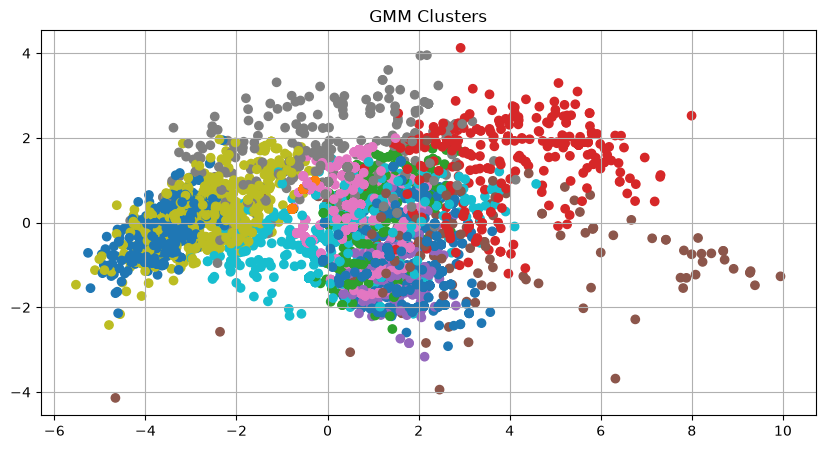

In [16]:
# Plot GMM clusters
plot_gmm(clusters, X)